<a href="https://colab.research.google.com/github/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/blob/main/Notebooks/neural_network_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NEURAL NETWORK FROM SCRATCH**

**IMPORT LIBRARIES**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**DEFINE CLASS**

In [68]:
class NeuralNetwork():

  """Representation of a neural network"""

  def __init__(self, learning_rate:int, layers:list, epochs:int):

    """Initialize the neural network"""

    self.learning_rate = learning_rate
    self.layers = layers
    self.epochs = epochs
    self.count_layers =len(layers)

  def initialize_weights(self ,input_size:int):

    """Initialize the weights of the neural network with random numbers between 1 and 0"""

    self.weights = []
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      if current_layer == 0:
        shape=(layer_size, input_size)
        self.weights.append(np.random.random_sample(shape))
      else:
        layer_before = current_layer-1
        layer_before_size = self.layers[layer_before]
        shape=(layer_size ,layer_before_size)
        self.weights.append(np.random.randn(*shape) *0.01)

  def initialize_biases(self):

    """Initialize the biases of the neural network with random numbers between 1 and 0"""

    self.biases=[]
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      shape=(layer_size,1)
      self.biases.append(np.zeros(shape))

  def get_activation(self,z):

    """Get the activation of the net input of a neural network"""

    return 1/(1+np.exp(-z))

  def get_layer_activations(self,sample_features):

    """Get the activation of the neurons of the neural network"""

    current_activations = sample_features
    layer_activations = []
    for current_layer in range(self.count_layers):
      current_activations= self.get_activation((self.weights[current_layer] @ current_activations)+self.biases[current_layer])
      layer_activations.append(current_activations)
    return layer_activations

  def backpropagation(self,layer_activations, sample,label):

    """Calculate the gradient of the weights and biases"""

    weights_gradients=[]
    biases_gradients=[]
    last_layer=self.count_layers-1
    first_layer=0
    for current_layer in range(last_layer,-1,-1):
      layer_activation= layer_activations[current_layer]
      activation_derivative = layer_activation*(1-layer_activation)
      if(current_layer == last_layer):cost_derivative = -1*((label-layer_activation)/(layer_activation*(1-layer_activation)))
      else: cost_derivative = np.transpose(self.weights[current_layer+1]) @ layer_errors
      layer_errors=cost_derivative * activation_derivative
      if(current_layer==first_layer): input_layer= np.transpose(sample)
      else:input_layer= np.transpose(layer_activations[current_layer-1])
      weights_derivative = layer_errors @ input_layer
      biases_derivative=layer_errors
      weights_gradients.insert(0,weights_derivative)
      biases_gradients.insert(0,biases_derivative)

    return weights_gradients, biases_gradients


  def optimization(self,weights_gradients,biases_gradients):

    "update the weights and the biases of the neural network to minimize the cost using gradient descent"

    for current_layer in range(self.count_layers):
      self.weights[current_layer] += -1*self.learning_rate*weights_gradients[current_layer]
      self.biases[current_layer] += -1*self.learning_rate*biases_gradients[current_layer]

  def fit(self, samples,labels):

    """Train neural network and stores cost history"""

    count_samples = samples.shape[0]
    count_features= samples.shape[1]
    self.initialize_weights(count_features)
    self.initialize_biases()
    self.cost_history=[]
    for i in range (self.epochs):
      cost = 0;
      for j in range (count_samples):
        sample = samples[j][:,None]
        label= labels[j]
        layer_activations=self.get_layer_activations(sample)
        prediction= layer_activations[-1]
        cost+=sum(-1*(label*np.log(prediction) + (1-label)*np.log(1-prediction)))
        weights_gradients, biases_gradients= self.backpropagation(layer_activations,sample,label)
        self.optimization(weights_gradients,biases_gradients)
      cost/=count_samples
      self.cost_history.append(cost)

  def plot_cost_history(self):

    """plot the value of the cost function for each epoch on the training process"""

    plt.plot(range(1,len(self.cost_history)+1),self.cost_history)
    plt.xlabel("epoch")
    plt.ylabel("cost")
    plt.title("history of cost function")


  def predict(self,sample):

    """Returns the activation of the last layout for a sample"""

    return self.get_layer_activations(sample)[-1][0]







# **TEST NEURAL NETWORK**

**UNIT TESTS**

In [29]:
#Test weights' initialization

model= NeuralNetwork(0.1,[2,2,1,2,1,1],5)
model.initialize_weights(3)
print(model.weights)

model= NeuralNetwork(0.1,[1,5,2,1],5)
model.initialize_weights(3)
print(model.weights)

[array([[0.03651661, 0.00672778, 0.3968729 ],
       [0.98578948, 0.04734874, 0.24538765]]), array([[ 0.01098808,  0.00994832],
       [-0.00191602, -0.00999287]]), array([[ 0.02130623, -0.01689595]]), array([[0.00388882],
       [0.00472477]]), array([[-0.00984571,  0.00758238]]), array([[0.00715569]])]
[array([[0.91702819, 0.39085369, 0.31079417]]), array([[0.00414827],
       [0.01518898],
       [0.02822531],
       [0.00623747],
       [0.00306841]]), array([[ 4.16887253e-03, -3.36637433e-02,  6.16474855e-05,
         4.31366999e-03,  7.77028555e-03],
       [ 6.61197625e-03,  3.77878209e-04, -4.28051610e-04,
         4.59521017e-03, -3.57862503e-03]]), array([[-0.0062551 , -0.00589333]])]


In [28]:
#Test biases' initialization

model= NeuralNetwork(0.1,[2,2,1,2,1,1],5)
model.initialize_biases()
print(model.biases)

model= NeuralNetwork(0.1,[1,5,2,1],5)
model.initialize_biases()
print(model.biases)

[array([[0.],
       [0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.]])]
[array([[0.]]), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]]), array([[0.],
       [0.]]), array([[0.]])]


In [35]:
#Test neuron' activations

model= NeuralNetwork(0.1,[2,1,1],5)
model.initialize_weights(1)
model.initialize_biases()
sample=np.array([1])[:,None]
print(model.weights , "\n")
print(model.biases , "\n")
print(model.get_layer_activations(sample))

[array([[0.10085854],
       [0.02977531]]), array([[-0.01778338, -0.00193189]]), array([[0.01244999]])] 

[array([[0.],
       [0.]]), array([[0.]]), array([[0.]])] 

[array([[0.52519328],
       [0.50744328]]), array([[0.49742001]]), array([[0.50154821]])]


# **EXPERIMENTS WITH NEURAL NETWORK**

**CHARGE SOCCER DATASET**

In [4]:
!wget https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
df=pd.read_csv('historical_european_soccer_matches.csv')

--2026-08-11 16:43:15--  https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2941531 (2.8M) [text/plain]
Saving to: ‘historical_european_soccer_matches.csv’

historical_european 100%[===================>]   2.80M  --.-KB/s    in 0.01s   

2026-08-11 16:43:15 (220 MB/s) - ‘historical_european_soccer_matches.csv’ saved [2941531/2941531]



**TRAIN NEURAL NETWORK**

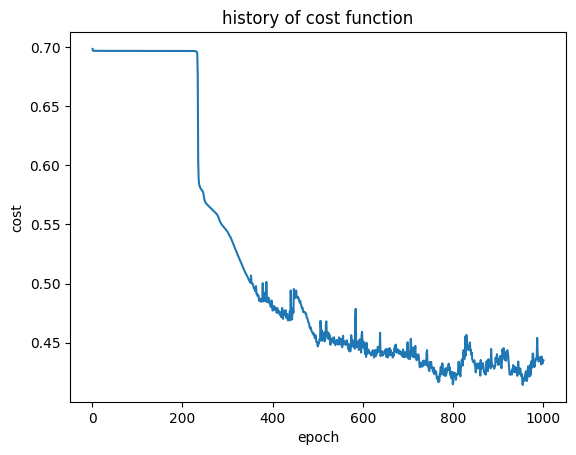

In [88]:
samples= df.iloc[:,:-1].values
labels= df.iloc[:,-1].values
model= NeuralNetwork(0.1,[110,55,25,12,1],1000)
model.fit(samples,labels)
model.plot_cost_history()

**ID OF TEAMS**

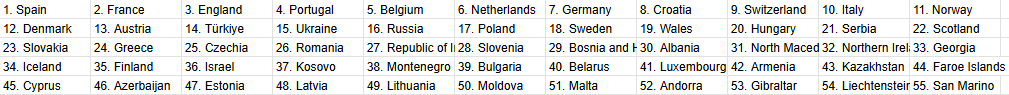

In [ ]:
while True:
  id_home_team=int(input("type a home team by its id : ")) - 1
  id_away_team=int(input("type a away team by its id : ")) + 54
  sample=np.zeros(110)
  sample[id_home_team]=1
  sample[id_away_team]=1
  sample=sample[:,None]
  if(round(model.predict(sample)[0])==1): print("The home team wins")
  else:print("The away team tie or wins")